# CogniNPC — Test 1: Benchmark wydajnosci i opoznien

 Wersja przeznaczona do generowania wynikow koncowych do pracy magisterskiej.

 **Zmienne niezalezne:** rozmiar modelu, wielkosc kontekstu RAG (k), wspolbieznosc (N)

 **Zmienne zalezne:** TTFT (stan ustalony i zimny start), TPS, czas calkowity,
 narzut orkiestracji, szczytowe zuzycie VRAM

 **Protokol:** rozgrzewka per warunek -> 30 powtorzen -> zapis surowych danych
 do JSONL -> analiza offline. Rozdzielenie zbierania od analizy pozwala
 przeliczac statystyki bez powtarzania kilkugodzinnego przebiegu.


In [ ]:
import json
import platform
import statistics
import subprocess
import threading
import time
import uuid
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timezone
from itertools import product
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

OUT = Path("results")
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)

API_URL = "http://localhost:8000/api/chat"

NPC_IDS = ["thorin_01", "elara_01"]

SEND_MODEL_PARAM = True
SEND_RAG_K_PARAM = True

# TODO: ADD MORE MODELS HERE
MODELS = ["llama3.1:latest"] if SEND_MODEL_PARAM else ["default"]
RAG_KS = [0, 3, 5, 10, 20] if SEND_RAG_K_PARAM else [None]
CONCURRENCIES = [1, 2, 4]
NUM_PREDICT = 128

# --- Protokol pomiarowy ----------------------------------------------------
REPETITIONS = 2                 # minimum dla sensownego p95 i przedzialu ufnosci
WARMUP = 3                      # odrzucane z analizy: eliminuja zimny start
COOLDOWN_S = 0.4                # ogranicza kumulacje ciepla i throttling GPU
MODEL_SWITCH_COOLDOWN_S = 20.0
TIMEOUT_S = 300.0
MAX_RETRIES = 2

# Prog detekcji przeladowania wag: WZGLEDNY, nie absolutny.
RELOAD_RATIO_THRESHOLD = 3.0

# --- Progi interpretacyjne (Nielsen 1993) ----------------------------------
# Uwaga: inferencja LLM jest asynchroniczna i NIE blokuje petli renderowania,
# wiec wlasciwym punktem odniesienia nie jest budzet klatki (16.6 ms), tylko
# progi percepcyjne interakcji konwersacyjnej.
T_FLOW_MS = 1000.0      # granica plynnosci toku myslenia
T_MASKED_MS = 2000.0    # akceptowalne przy maskowaniu animacja "NPC mysli"
T_BREAK_MS = 10000.0    # utrata uwagi uzytkownika

# --- Zestaw promptow --------------------------------------------------------
# Klasa promptu jest wspolzmienna kontrolowana: rotujemy je rownomiernie,
# zeby wynik nie zalezal od jednego szczegolnie latwego zapytania.
TEST_PROMPTS = [
    ("krotki", "Hello."),
    ("tozsamosc", "Who are you and what do you do here?"),
    ("prosba", "Can you forge a magical sword for me?"),
    ("emocjonalny", "What is your opinion on magic and elves? I heard you hate them."),
    ("zlozony", "I need a complete set of steel armor, a shield, and a heavy warhammer. "
                "How much will it cost and how long will it take?"),
]

RUN_ID = uuid.uuid4().hex[:12]
#RUN_ID = "08df3ac72878"
RAW_PATH = OUT / f"raw_{RUN_ID}.jsonl"
print(f"run_id = {RUN_ID}\nsurowe dane -> {RAW_PATH}")


run_id = a92e8c347ce4
surowe dane -> results/raw_a92e8c347ce4.jsonl


 ## 2. Wymagane pola po stronie backendu

 `/api/chat` musi przyjmowac `model`, `rag_k`, `num_predict` oraz
 `skip_memory_write` (patrz patch_schemas.py / patch_npc_service.py /
 patch_router.py / patch_ollama_service.py), a `metrics` w odpowiedzi musi
 zawierac WSZYSTKIE ponizsze klucze — brak ktoregokolwiek cicho zeruje
 odpowiadajaca mu kolumne w analizie zamiast rzucic bledem:

 - `prompt_eval_count`  -> wyjasnia mechanizm wplywu rag_k na TTFT
 - `total_duration`     -> bez tego ollama_total_ms=0 i orchestration_ms
                           falszywie rowna sie calemu wall_ms (tak bylo
                           w przebiegu testowym z REPETITIONS=5)

 response_chars w analizie czyta klucz `response_text` z ChatResponse —
 jesli nazwa pola w Twoim schemacie jest inna, zmien w single_request().

## 3. Telemetria VRAM i metadane srodowiska

In [67]:
def nvidia_query(field: str) -> str | None:
    try:
        out = subprocess.check_output(
            ["nvidia-smi", f"--query-gpu={field}", "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL, timeout=5,
        )
        return out.decode().strip().splitlines()[0].strip()
    except Exception:
        return None


class VramSampler:
    """Probkuje zajetosc VRAM w watku tla; raportuje wartosc szczytowa."""

    def __init__(self, interval_s: float = 0.25):
        self.interval_s = interval_s
        self._stop = threading.Event()
        self._thread: threading.Thread | None = None
        self._samples: list[float] = []
        self.available = nvidia_query("memory.used") is not None

    def _loop(self):
        while not self._stop.is_set():
            v = nvidia_query("memory.used")
            if v:
                try:
                    self._samples.append(float(v))
                except ValueError:
                    pass
            self._stop.wait(self.interval_s)

    def start(self):
        if not self.available:
            return
        self._samples = []
        self._stop.clear()
        self._thread = threading.Thread(target=self._loop, daemon=True)
        self._thread.start()

    def stop(self) -> dict:
        if not self.available:
            return {}
        self._stop.set()
        if self._thread:
            self._thread.join(timeout=2.0)
        if not self._samples:
            return {}
        return {
            "vram_peak_mb": round(max(self._samples), 1),
            "vram_mean_mb": round(statistics.fmean(self._samples), 1),
        }


def env_fingerprint() -> dict:
    def sh(cmd):
        try:
            return subprocess.check_output(cmd, stderr=subprocess.DEVNULL, timeout=10).decode().strip()
        except Exception:
            return None

    return {
        "git_commit": sh(["git", "rev-parse", "--short", "HEAD"]),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "gpu_name": nvidia_query("name"),
        "gpu_total_vram_mb": nvidia_query("memory.total"),
        "driver": nvidia_query("driver_version"),
    }


ENV = env_fingerprint()
print(json.dumps(ENV, indent=2, ensure_ascii=False))

{
  "git_commit": "28201e3",
  "python": "3.13.9",
  "platform": "Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35",
  "gpu_name": "NVIDIA GeForce RTX 5070 Ti",
  "gpu_total_vram_mb": "16303",
  "driver": "610.74"
}


## 4. Pojedyncze wywolanie i dekompozycja metryk

In [68]:
NS_TO_MS = 1e6

def parse_metrics(m: dict, baseline_load_ms: float | None = None) -> dict:
    """Przelicza natywne liczniki Ollamy (nanosekundy) na milisekundy.

    Rozdzielenie TTFT na wariant zimny i cieply jest istotne metodologicznie:
    `load_duration` jest niezerowe TYLKO gdy nastapilo ladowanie wag do VRAM.
    Wliczanie go do kazdego pomiaru mieszalo by dwa rozne zjawiska —
    jednorazowy koszt startu gry i powtarzalny koszt kazdej wypowiedzi.
    """
    load_ms = m.get("load_duration", 0) / NS_TO_MS
    prefill_ms = m.get("prompt_eval_duration", 0) / NS_TO_MS
    decode_ms = m.get("eval_duration", 0) / NS_TO_MS
    ollama_total_ms = m.get("total_duration", 0) / NS_TO_MS

    prompt_tokens = m.get("prompt_eval_count", 0)
    output_tokens = m.get("eval_count", 0)

    if baseline_load_ms and baseline_load_ms > 0:
        reloaded = RELOAD_RATIO_THRESHOLD > 3 * baseline_load_ms
    else:
        reloaded = False

    return {
        "llm_error": m.get("error"),
        "load_ms": round(load_ms, 2),
        "model_reloaded": reloaded,
        # Stan ustalony — to odczuwa gracz podczas rozgrywki:
        "ttft_warm_ms": round(prefill_ms, 2),
        # Pierwsza interakcja po uruchomieniu gry:
        "ttft_cold_ms": round(load_ms + prefill_ms, 2),
        "decode_ms": round(decode_ms, 2),
        "ollama_total_ms": round(ollama_total_ms, 2),
        "prompt_tokens": prompt_tokens,
        "output_tokens": output_tokens,
        # Normalizacja dlugosci wypowiedzi. Bez niej porownanie 8B vs 3.8B
        # jest bezwartosciowe: mniejszy model moze po prostu generowac dluzej.
        "tps": round(output_tokens / (decode_ms / 1000), 2) if decode_ms > 0 else None,
        "prefill_tps": round(prompt_tokens / (prefill_ms / 1000), 2) if prefill_ms > 0 else None,
    }


def single_request(client: httpx.Client, npc_id: str, prompt: str,
                   model: str, rag_k, prompt_class: str,
                   baseline_load_ms: float | None = None) -> dict:
    payload = {
        "npc_id": npc_id,
        "player_message": prompt,
        "skip_memory_write": True,
        "num_predict": NUM_PREDICT
        }
    if SEND_MODEL_PARAM:
        payload["model"] = model
    if SEND_RAG_K_PARAM and rag_k is not None:
        payload["rag_k"] = rag_k

    last_err = None
    for attempt in range(MAX_RETRIES + 1):
        # perf_counter, nie time.time() — tylko ten pierwszy jest monotoniczny
        # i odporny na korekty zegara systemowego w trakcie dlugiego przebiegu.
        t0 = time.perf_counter()
        try:
            r = client.post(API_URL, json=payload)
            wall_ms = (time.perf_counter() - t0) * 1000
            r.raise_for_status()
            body = r.json()
            rec = {"ok": True, "attempt": attempt, "wall_ms": round(wall_ms, 2)}
            rec.update(parse_metrics(body.get("metrics", {})))

            resp_text = body.get("response_text", "") or ""
            rec["response_chars"] = len(resp_text)

            rec["response_preview"] = resp_text[:150]
            rec["prompt_class"] = prompt_class

            # Wszystko, czego nie robi Ollama: embedding, ChromaDB, budowa
            # promptu, serializacja FastAPI, transport HTTP. Ta liczba
            # opisuje koszt Twojego orkiestratora, nie modelu.
            rec["orchestration_ms"] = round(wall_ms - rec["ollama_total_ms"], 2)
            return rec
        except Exception as exc:
            last_err = f"{type(exc).__name__}: {exc}"
            time.sleep(1.0)

    return {"ok": False, "error": last_err, "prompt_class": prompt_class,
            "attempt": MAX_RETRIES}

## 5. Wykonanie serii wspolbieznej

Ollama serializuje czesc pracy na jednym GPU, wiec latencja przy N=1 nie
mowi nic o scenie, w ktorej rozmawia kilku NPC jednoczesnie. Zakres
ograniczono do N<=4, co odpowiada realistycznej gestosci rownoczesnych
interakcji w scenie RPG przy pojedynczej karcie graficznej.

In [69]:
def run_batch(client: httpx.Client, model: str, rag_k, concurrency: int, rep: int,
              baseline_load_ms: float | None = None) -> list[dict]:
    jobs = []
    for slot in range(concurrency):
        npc_id = NPC_IDS[slot % len(NPC_IDS)]
        cls, prompt = TEST_PROMPTS[(rep + slot) % len(TEST_PROMPTS)]
        jobs.append((npc_id, prompt, cls))

    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=concurrency) as ex:
        futures = [
            ex.submit(single_request, client, npc, pr, model, rag_k, cls, baseline_load_ms)
            for npc, pr, cls in jobs
        ]
        results = [f.result() for f in futures]
    batch_ms = (time.perf_counter() - t0) * 1000

    for slot, rec in enumerate(results):
        rec["slot"] = slot
        # Czas domkniecia calej sceny — dla gracza istotniejszy niz czas
        # pojedynczej odpowiedzi, gdy w tle rozmawia kilku NPC.
        rec["batch_wall_ms"] = round(batch_ms, 2)
    return results

## 6. Glowna petla eksperymentu

Kolejnosc iteracji ustawiona tak, by model zmienial sie najwolniej —
minimalizuje to liczbe przeladowan wag do VRAM.

In [70]:
conditions = [
    {"model": m, "rag_k": k, "concurrency": c}
    for m, c, k in product(MODELS, CONCURRENCIES, RAG_KS)
]
n_requests = sum(c["concurrency"] * (REPETITIONS + WARMUP) for c in conditions)
print(f"Warunkow: {len(conditions)} | Zadan lacznie: ~{n_requests}")

sampler = VramSampler()
if not sampler.available:
    print("UWAGA: nvidia-smi niedostepne — pomiar VRAM zostanie pominiety.")

last_model = None
t_start = time.perf_counter()

with RAW_PATH.open("w", encoding="utf-8") as fh, \
     httpx.Client(timeout=TIMEOUT_S, limits=httpx.Limits(max_connections=32)) as client:

    for ci, cond in enumerate(conditions, 1):
        model, rag_k, conc = cond["model"], cond["rag_k"], cond["concurrency"]

        if last_model is not None and model != last_model:
            print(f"  [zmiana modelu -> {model}] cooldown {MODEL_SWITCH_COOLDOWN_S}s")
            time.sleep(MODEL_SWITCH_COOLDOWN_S)
        last_model = model

        label = f"{model} | k={rag_k} | N={conc}"
        print(f"[{ci}/{len(conditions)}] {label}", flush=True)

        # Rozgrzewka: absorbuje ladowanie wag i inicjalizacje polaczen HTTP.
        warmup_load_samples = []
        for w in range(WARMUP):
            recs = run_batch(client, model, rag_k, conc, rep=w)
            warmup_load_samples += [r["load_ms"] for r in recs if r.get("ok") and "load_ms" in r]
            time.sleep(COOLDOWN_S)

        baseline_load_ms = (
            statistics.median(warmup_load_samples) if warmup_load_samples else None
        )
        if baseline_load_ms:
            print(f"      baseline load_ms (z rozgrzewki): {baseline_load_ms:.1f}")

        sampler.start()
        for rep in range(REPETITIONS):
            recs = run_batch(client, model, rag_k, conc, rep, baseline_load_ms)
            for rec in recs:
                fh.write(json.dumps({
                    "run_id": RUN_ID,
                    "ts": datetime.now(timezone.utc).isoformat(),
                    "rep": rep,
                    **cond,
                    **rec,
                    **{f"env_{k}": v for k, v in ENV.items()},
                }, ensure_ascii=False) + "\n")
            fh.flush()
            time.sleep(COOLDOWN_S)
        vram = sampler.stop()

        # VRAM przypisujemy do warunku, nie do pojedynczego zadania.
        if vram:
            fh.write(json.dumps({
                "run_id": RUN_ID, "record_type": "vram_summary",
                **cond, **vram,
            }, ensure_ascii=False) + "\n")
            fh.flush()
            print(f"      VRAM szczyt: {vram['vram_peak_mb']:.0f} MB")

print(f"\nZakonczono w {(time.perf_counter() - t_start)/60:.1f} min -> {RAW_PATH}")

Warunkow: 15 | Zadan lacznie: ~175
[1/15] llama3.1:latest | k=0 | N=1


      baseline load_ms (z rozgrzewki): 173.2
      VRAM szczyt: 6707 MB
[2/15] llama3.1:latest | k=3 | N=1
      baseline load_ms (z rozgrzewki): 163.1
      VRAM szczyt: 6678 MB
[3/15] llama3.1:latest | k=5 | N=1
      baseline load_ms (z rozgrzewki): 165.9
      VRAM szczyt: 6648 MB
[4/15] llama3.1:latest | k=10 | N=1
      baseline load_ms (z rozgrzewki): 170.0
      VRAM szczyt: 6631 MB
[5/15] llama3.1:latest | k=20 | N=1
      baseline load_ms (z rozgrzewki): 166.7
      VRAM szczyt: 6631 MB
[6/15] llama3.1:latest | k=0 | N=2
      baseline load_ms (z rozgrzewki): 182.6
      VRAM szczyt: 6631 MB
[7/15] llama3.1:latest | k=3 | N=2
      baseline load_ms (z rozgrzewki): 201.6
      VRAM szczyt: 6634 MB
[8/15] llama3.1:latest | k=5 | N=2
      baseline load_ms (z rozgrzewki): 191.1
      VRAM szczyt: 6654 MB
[9/15] llama3.1:latest | k=10 | N=2
      baseline load_ms (z rozgrzewki): 219.4
      VRAM szczyt: 6712 MB
[10/15] llama3.1:latest | k=20 | N=2
      baseline load_ms (z rozgrz

## ANALIZA

Ponizsza czesc czyta wylacznie plik JSONL — mozna ja uruchamiac dowolnie
wiele razy bez powtarzania benchmarku.

In [71]:
rows = [json.loads(l) for l in RAW_PATH.read_text(encoding="utf-8").splitlines() if l.strip()]
df_all = pd.DataFrame(rows)

vram_df = df_all[df_all.get("record_type") == "vram_summary"] if "record_type" in df_all else pd.DataFrame()
if "record_type" in df_all.columns:
    record_type = df_all["record_type"]
    vram_df = df_all[record_type == "vram_summary"]
    df = df_all[record_type.isna()]
else:
    vram_df = pd.DataFrame()
    df = df_all

n_total = len(df)
df = df[df["ok"] == True].copy()  # noqa: E712
print(f"Rekordow: {n_total} | poprawnych: {len(df)} ({len(df)/max(n_total,1):.1%})")

if n_total - len(df) > 0:
    print("\nRozklad bledow:")
    print(pd.DataFrame(rows).query("ok == False")["error"].value_counts().head())

# DIAGNOSTYKA: request moze zwrocic HTTP 200 (ok=True), a mimo to zawierac
# blad WEWNATRZ backendu — np. gdy OllamaService nie mogl polaczyc sie z
# Ollama i zwrocil komunikat awaryjny jako response_text zamiast rzucic
# wyjatek.
_llm_errors = df["llm_error"].dropna() if "llm_error" in df else pd.Series(dtype=object)
if not _llm_errors.empty:
    print(f"\n!!! WYKRYTO {len(_llm_errors)} rekordow z bledem WEWNATRZ backendu (HTTP=200, ale generacja nie powiodla sie):")
    print(_llm_errors.value_counts().head(10))
    print("\nPrzyklad tresci odpowiedzi zwroconej zamiast generacji:")
    print(df.loc[_llm_errors.index[0], "response_preview"])
elif (df["prompt_tokens"] == 0).all():
    print("\n!!! UWAGA: prompt_tokens=0 dla WSZYSTKICH rekordow mimo braku pola llm_error.")
    print("To sugeruje, ze backend nie zwraca total_duration/prompt_eval_count w metrics,")
    print("albo generacja faktycznie nie doszla do skutku. Przyklad odpowiedzi:")
    print(df["response_preview"].iloc[0])

# Przeladowania wag to inne zjawisko niz normalna generacja — analizujemy je
# osobno, zamiast pozwolic im zaburzyc mediane stanu ustalonego.
reloads = df[df["model_reloaded"] == True]  # noqa: E712
print(f"\nWykrytych przeladowan modelu w fazie pomiarowej: {len(reloads)}")
if len(reloads):
    print("  -> te rekordy zostaja wylaczone z analizy stanu ustalonego")
    print(f"  -> mediana zimnego startu: {reloads['ttft_cold_ms'].median():.0f} ms")

df_warm = df[df["model_reloaded"] == False].copy()  # noqa: E712

# Metryka wyprowadzona: rzeczywisty czas oczekiwania w kolejce Ollamy.
# Ollama zwraca total_duration OBEJMUJACE czas oczekiwania na wolny slot
# przetwarzania, natomiast load_duration/prompt_eval_duration/eval_duration
# mierza WYLACZNIE aktywne fazy przetwarzania. Roznica miedzy nimi to
# rzeczywiste, sprzetowe/konfiguracyjne ograniczenie (prawdopodobnie
# OLLAMA_NUM_PARALLEL=1 — jeden slot generacji na GPU), NIE blad
# orkiestracji — ten drugi zostal juz wyeliminowany (patrz orchestration_ms,
# ktore po poprawce routera pozostaje mala, plaska wartoscia niezaleznie od N).
df_warm["ollama_queue_ms"] = (
    df_warm["ollama_total_ms"]
    - (df_warm["load_ms"] + df_warm["ttft_warm_ms"] + df_warm["decode_ms"])
).clip(lower=0)

Rekordow: 70 | poprawnych: 70 (100.0%)

Wykrytych przeladowan modelu w fazie pomiarowej: 0


## 7. Tabela zbiorcza

In [72]:
def bootstrap_ci_median(x, n_boot=5000, alpha=0.05):
    """Przedzial ufnosci dla mediany metoda percentylowa.

    Rozklady latencji sa prawoskosne, wiec CI oparte na zalozeniu normalnosci
    byloby tu nieuprawnione. Bootstrap nie wymaga zalozen o ksztalcie rozkladu.
    """
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) < 5:
        return (np.nan, np.nan)
    rng = np.random.default_rng(42)
    boots = np.median(rng.choice(x, size=(n_boot, len(x)), replace=True), axis=1)
    return float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


def summarize(df_in: pd.DataFrame) -> pd.DataFrame:
    keys = ["model", "rag_k", "concurrency"]
    out = []
    for name, g in df_in.groupby(keys, dropna=False):
        row = dict(zip(keys, name if isinstance(name, tuple) else (name,)))
        row["n"] = len(g)
        for label, col in [("ttft", "ttft_warm_ms"), ("decode", "decode_ms"),
                           ("wall", "wall_ms"), ("orch", "orchestration_ms"),
                           ("ollama_queue", "ollama_queue_ms")]:
            if col not in g:
                continue

            v = g[col].dropna()
            if v.empty:
                continue
            row[f"{label}_med"] = round(v.median(), 1)

            lo, hi = bootstrap_ci_median(v)
            row[f"{label}_ci95"] = f"[{lo:.0f}, {hi:.0f}]"
            row[f"{label}_p95"] = round(np.percentile(v, 95), 1)

        row["tps_med"] = round(df_in.loc[g.index, "tps"].median(), 1)
        row["prompt_tok_med"] = round(g["prompt_tokens"].median(), 0)
        row["out_tok_med"] = round(g["output_tokens"].median(), 0)
        # Operacyjna definicja grywalnosci: odsetek odpowiedzi miesczacych sie
        # w budzecie maskowania animacja.
        row["pct_pod_2s"] = round((g["wall_ms"] < T_MASKED_MS).mean() * 100, 1)
        out.append(row)
    if not out:
        return pd.DataFrame(columns=keys)
    return pd.DataFrame(out).sort_values(keys)


summary = summarize(df_warm)
summary.to_csv(OUT / "tables" / "summary.csv", index=False)
display(summary)

,model,rag_k,concurrency,n,ttft_med,ttft_ci95,ttft_p95,decode_med,decode_ci95,decode_p95,...,orch_med,orch_ci95,orch_p95,ollama_queue_med,ollama_queue_ci95,ollama_queue_p95,tps_med,prompt_tok_med,out_tok_med,pct_pod_2s
0,llama3.1:latest,0,1,2,16.9,"[nan, nan]",17.4,166.8,"[nan, nan]",188.2,...,14.3,"[nan, nan]",14.6,4.1,"[nan, nan]",4.4,113.6,518.0,19.0,100.0
1,llama3.1:latest,0,2,4,20.9,"[nan, nan]",58.8,498.1,"[nan, nan]",745.2,...,15.4,"[nan, nan]",16.8,196.8,"[nan, nan]",768.6,117.8,522.0,58.0,100.0
2,llama3.1:latest,0,4,8,19.0,"[17, 51]",52.9,589.1,"[193, 862]",903.7,...,22.9,"[21, 24]",23.9,822.6,"[60, 1389]",1955.5,111.3,524.0,65.0,62.5
3,llama3.1:latest,3,1,2,17.6,"[nan, nan]",18.3,250.8,"[nan, nan]",329.1,...,46.5,"[nan, nan]",46.8,4.0,"[nan, nan]",4.1,114.3,574.0,28.0,100.0
4,llama3.1:latest,3,2,4,17.1,"[nan, nan]",18.0,454.5,"[nan, nan]",576.6,...,61.4,"[nan, nan]",69.1,350.5,"[nan, nan]",684.1,116.7,547.0,52.0,100.0
5,llama3.1:latest,3,4,8,17.4,"[16, 18]",34.0,479.9,"[216, 791]",808.7,...,78.3,"[68, 99]",101.6,601.4,"[61, 1465]",1671.6,117.9,557.0,56.0,62.5
6,llama3.1:latest,5,1,2,17.2,"[nan, nan]",18.4,290.6,"[nan, nan]",399.0,...,55.1,"[nan, nan]",56.3,3.9,"[nan, nan]",4.0,103.0,574.0,31.0,100.0
7,llama3.1:latest,5,2,4,17.3,"[nan, nan]",18.9,471.5,"[nan, nan]",652.0,...,62.6,"[nan, nan]",88.1,231.9,"[nan, nan]",720.4,111.9,547.0,54.0,100.0
8,llama3.1:latest,5,4,8,17.2,"[17, 35]",36.0,625.8,"[449, 861]",1031.6,...,86.3,"[77, 94]",104.0,1076.8,"[53, 2030]",2335.0,111.8,557.0,71.0,37.5
9,llama3.1:latest,10,1,2,16.4,"[nan, nan]",16.5,236.2,"[nan, nan]",298.3,...,48.9,"[nan, nan]",54.5,3.9,"[nan, nan]",3.9,118.8,574.0,28.0,100.0


In [73]:
# Tabela VRAM — bezposrednia odpowiedz na pytanie o wykonalnosc sprzetowa.
if not vram_df.empty:
    vram_tab = (vram_df.groupby(["model", "rag_k"])["vram_peak_mb"]
                .max().reset_index()
                .rename(columns={"vram_peak_mb": "VRAM szczyt [MB]"}))
    vram_tab["VRAM szczyt [GB]"] = (vram_tab["VRAM szczyt [MB]"] / 1024).round(2)
    vram_tab.to_csv(OUT / "tables" / "vram.csv", index=False)
    display(vram_tab)
    print(f"Karta testowa: {ENV.get('gpu_name')} ({ENV.get('gpu_total_vram_mb')} MB)")

,model,rag_k,VRAM szczyt [MB],VRAM szczyt [GB]
0,llama3.1:latest,0,6766.0,6.61
1,llama3.1:latest,3,6742.0,6.58
2,llama3.1:latest,5,6744.0,6.59
3,llama3.1:latest,10,6749.0,6.59
4,llama3.1:latest,20,6795.0,6.64


Karta testowa: NVIDIA GeForce RTX 5070 Ti (16303 MB)


## 8. Wykresy

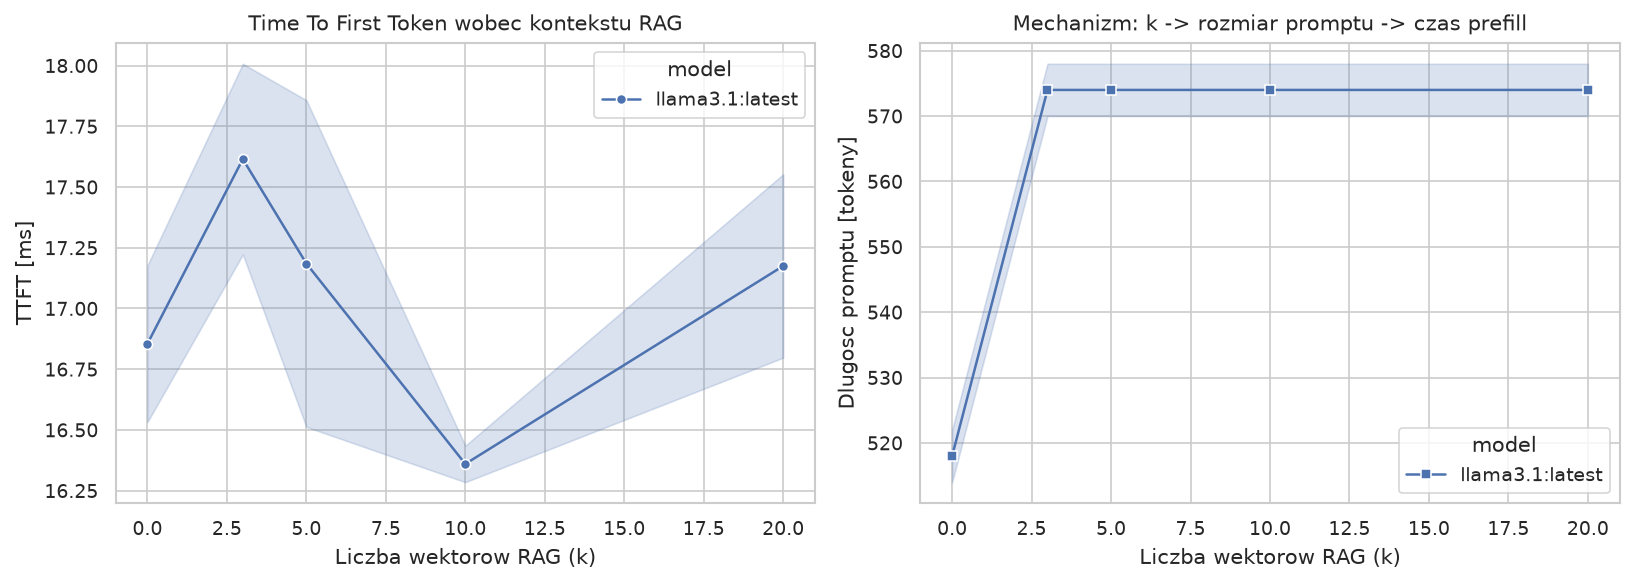

In [74]:
def save_fig(fig, name):
    for ext in ("png", "pdf"):  # PDF = grafika wektorowa do wersji drukowanej
        fig.savefig(OUT / "figures" / f"{name}.{ext}")


# --- Rys. 1: wplyw kontekstu RAG na TTFT + mechanizm ------------------------
if len(RAG_KS) > 1:
    d1 = df_warm[df_warm["concurrency"] == 1]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.lineplot(data=d1, x="rag_k", y="ttft_warm_ms", hue="model", marker="o",
                 estimator="median", errorbar=("pi", 50), ax=axes[0])
    axes[0].set(xlabel="Liczba wektorow RAG (k)", ylabel="TTFT [ms]",
                title="Time To First Token wobec kontekstu RAG")
    sns.lineplot(data=d1, x="rag_k", y="prompt_tokens", hue="model", marker="s",
                 estimator="median", ax=axes[1])
    axes[1].set(xlabel="Liczba wektorow RAG (k)", ylabel="Dlugosc promptu [tokeny]",
                title="Mechanizm: k -> rozmiar promptu -> czas prefill")
    fig.tight_layout()
    save_fig(fig, "rys1_wplyw_rag")
    plt.show()

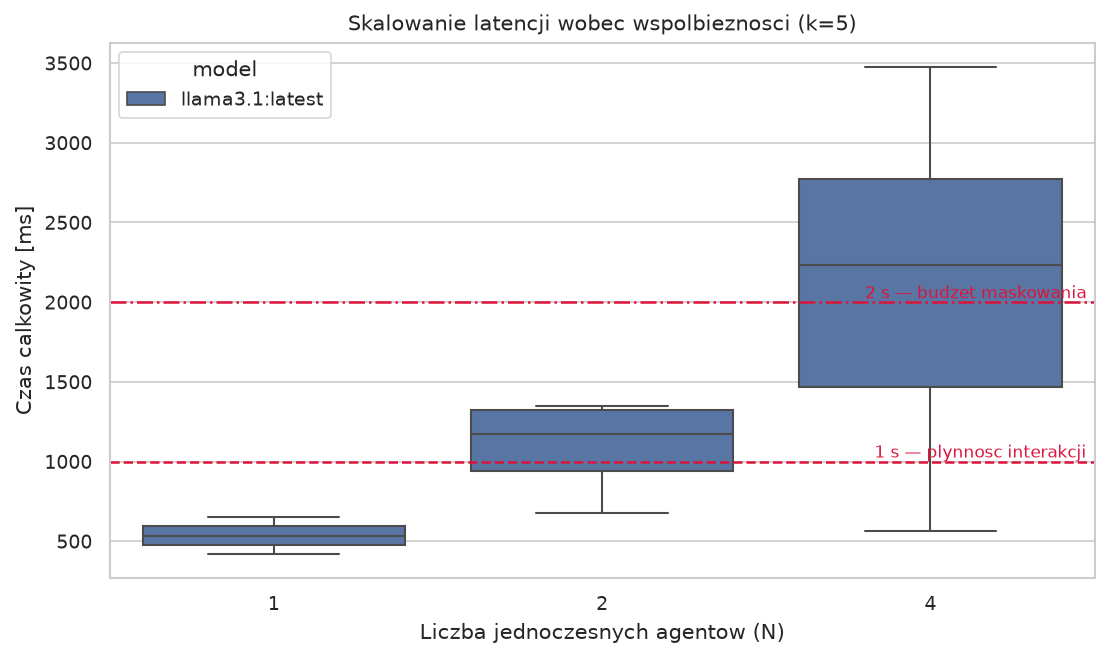

In [75]:
# --- Rys. 2: skalowanie przy wspolbieznosci --------------------------------
mid_k = RAG_KS[len(RAG_KS) // 2]
d2 = df_warm[df_warm["rag_k"] == mid_k] if mid_k is not None else df_warm

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(data=d2, x="concurrency", y="wall_ms", hue="model", showfliers=False, ax=ax)
for y, lbl, ls in [(T_FLOW_MS, "1 s — plynnosc interakcji", "--"),
                   (T_MASKED_MS, "2 s — budzet maskowania", "-.")]:
    ax.axhline(y, ls=ls, lw=1.2, color="crimson")
    ax.text(ax.get_xlim()[1] * 0.99, y, f" {lbl}", va="bottom", ha="right",
            fontsize=8, color="crimson")
ax.set(xlabel="Liczba jednoczesnych agentow (N)", ylabel="Czas calkowity [ms]",
       title=f"Skalowanie latencji wobec wspolbieznosci (k={mid_k})")
fig.tight_layout()
save_fig(fig, "rys2_wspolbieznosc")
plt.show()

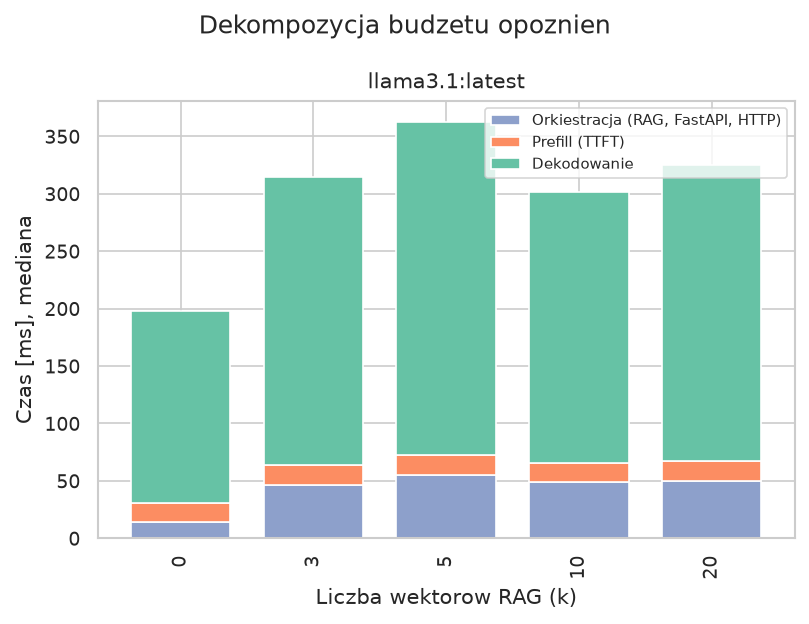

In [76]:
# --- Rys. 3: dekompozycja budzetu opoznien ---------------------------------
# Pokazuje, ile kosztuje Twoj orkiestrator wzgledem samej inferencji.
d3 = (df_warm[df_warm["concurrency"] == 1]
      .groupby(["model", "rag_k"], dropna=False)[["orchestration_ms", "ttft_warm_ms", "decode_ms"]]
      .median().reset_index())

models = sorted(d3["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5.5 * len(models), 4.2),
                         sharey=True, squeeze=False)
for ax, m in zip(axes[0], models):
    sub = d3[d3["model"] == m].set_index("rag_k")[["orchestration_ms", "ttft_warm_ms", "decode_ms"]]
    sub.columns = ["Orkiestracja (RAG, FastAPI, HTTP)", "Prefill (TTFT)", "Dekodowanie"]
    sub.plot(kind="bar", stacked=True, ax=ax, width=0.75,
             color=["#8da0cb", "#fc8d62", "#66c2a5"])
    ax.set(xlabel="Liczba wektorow RAG (k)", title=m)
    ax.legend(fontsize=7)
axes[0][0].set_ylabel("Czas [ms], mediana")
fig.suptitle("Dekompozycja budzetu opoznien")
fig.tight_layout()
save_fig(fig, "rys3_dekompozycja")
plt.show()

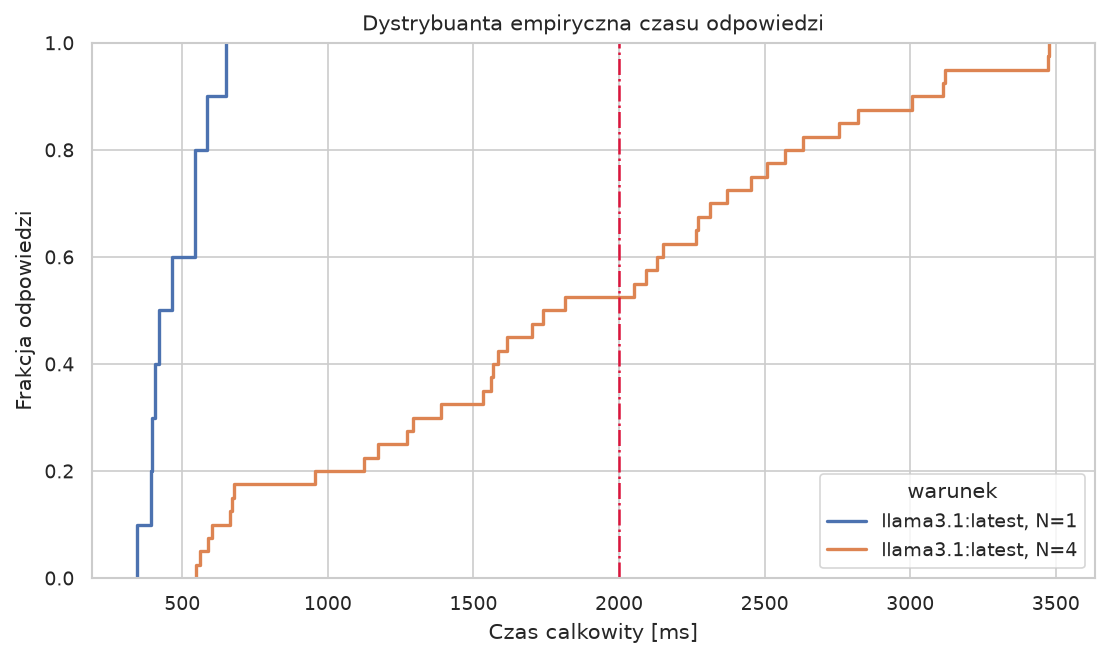

In [77]:
# --- Rys. 4: dystrybuanta empiryczna ---------------------------------------
# Czytelniejsza niz histogram dla ogonow rozkladu — a to ogony decyduja
# o tym, czy gracz odczuje "zacinanie sie" dialogow.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
d4 = df_warm[df_warm["concurrency"].isin([1, max(CONCURRENCIES)])].copy()
d4["warunek"] = d4["model"] + ", N=" + d4["concurrency"].astype(str) # type: ignore
sns.ecdfplot(data=d4, x="wall_ms", hue="warunek", ax=ax, lw=1.6)
ax.axvline(T_MASKED_MS, ls="-.", color="crimson", lw=1.2)
ax.set(xlabel="Czas calkowity [ms]", ylabel="Frakcja odpowiedzi",
       title="Dystrybuanta empiryczna czasu odpowiedzi")
fig.tight_layout()
save_fig(fig, "rys4_dystrybuanta")
plt.show()


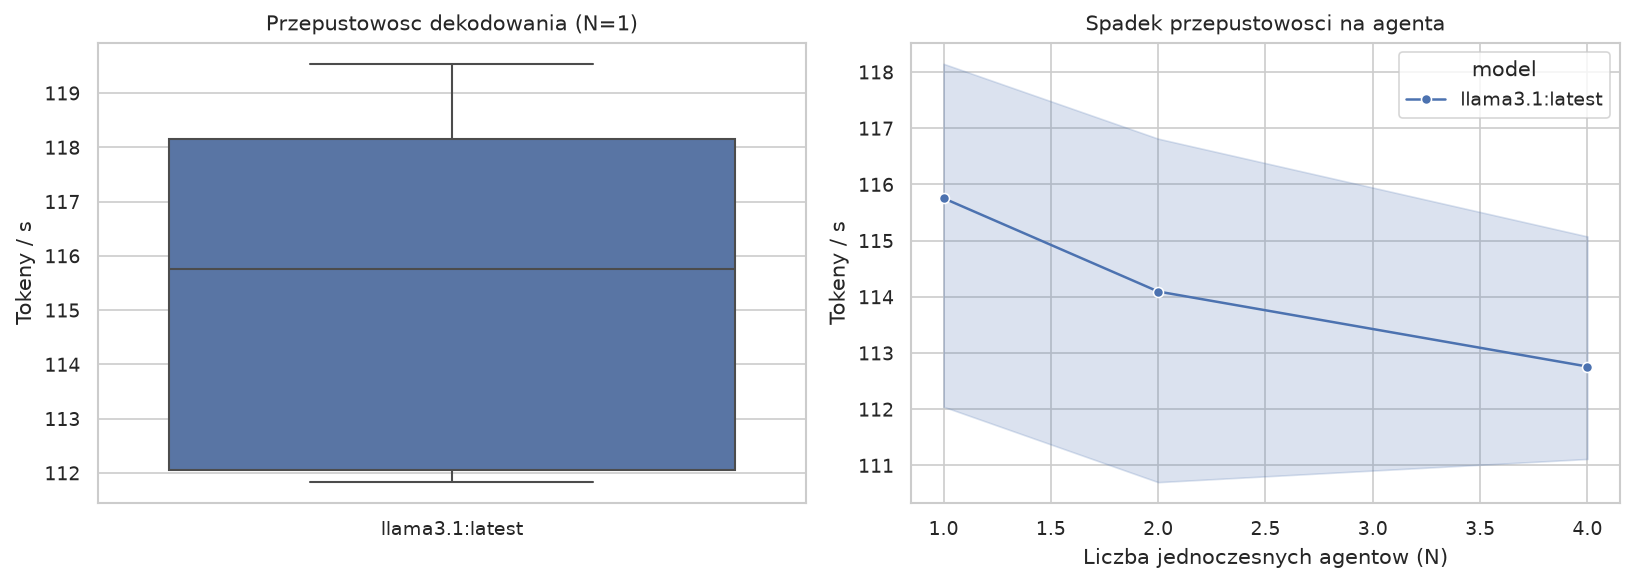

In [78]:
# --- Rys. 5: przepustowosc TPS ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df_warm[df_warm["concurrency"] == 1], x="model", y="tps",
            showfliers=False, ax=axes[0])
axes[0].set(xlabel="", ylabel="Tokeny / s", title="Przepustowosc dekodowania (N=1)")
sns.lineplot(data=df_warm, x="concurrency", y="tps", hue="model", marker="o",
             estimator="median", errorbar=("pi", 50), ax=axes[1])
axes[1].set(xlabel="Liczba jednoczesnych agentow (N)", ylabel="Tokeny / s",
            title="Spadek przepustowosci na agenta")
fig.tight_layout()
save_fig(fig, "rys5_przepustowosc")
plt.show()


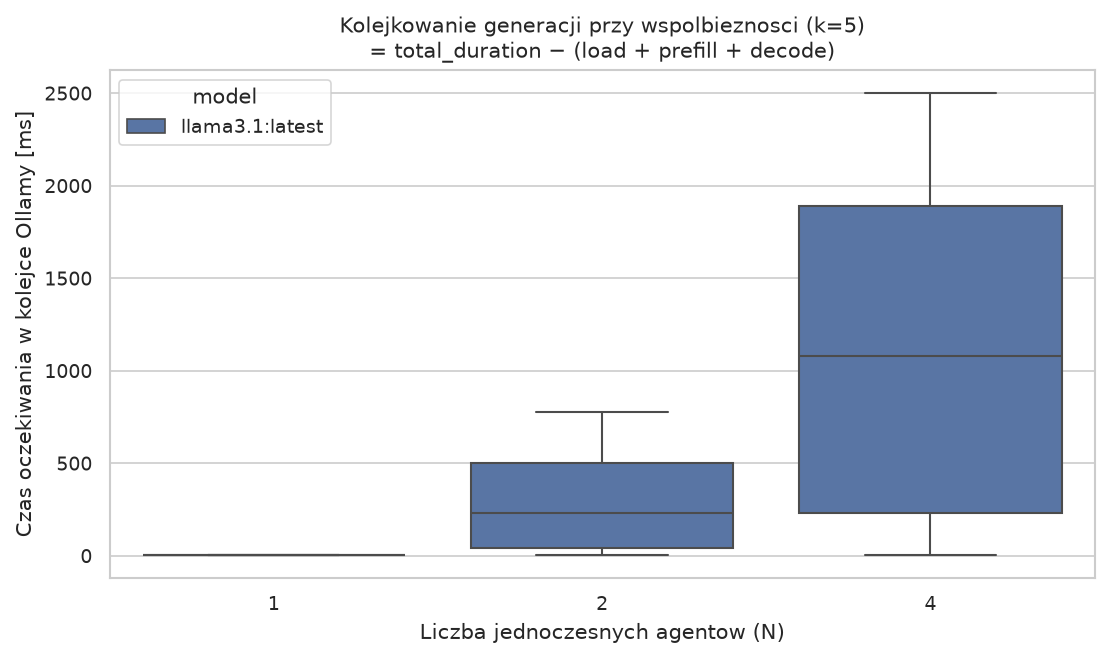

In [79]:
# --- Rys. 6: kolejkowanie po stronie Ollamy vs wspolbieznosc ---------------
# TO JEST GLOWNY WYNIK CZESCI O WSPOLBIEZNOSCI. Pokazuje, ze narzut przy
# rosnacym N pochodzi niemal wylacznie z wewnetrznej kolejki Ollamy (jeden
# slot generacji na GPU), a NIE z warstwy orkiestracji FastAPI/RAG —
# orchestration_ms pozostaje plaskie niezaleznie od N (patrz rys. 2/tabela).
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(data=df_warm[df_warm["rag_k"] == 5], x="concurrency",
            y="ollama_queue_ms", hue="model", showfliers=False, ax=ax)
ax.set(xlabel="Liczba jednoczesnych agentow (N)",
       ylabel="Czas oczekiwania w kolejce Ollamy [ms]",
       title="Kolejkowanie generacji przy wspolbieznosci (k=5)\n"
             "= total_duration − (load + prefill + decode)")
fig.tight_layout()
save_fig(fig, "rys6_kolejkowanie_ollama")
plt.show()

## 9. Ekstrapolacja kosztu — argument za rozwiazaniem lokalnym

UWAGA: cennik nalezy zweryfikowac i zacytowac z data dostepu. Ponizsze
wartosci sa przykladowe i wymagaja aktualizacji przed zlozeniem pracy.

Sformulowanie w tekscie: rozwiazanie lokalne charakteryzuje sie **kosztem
krancowym zapytania blizkim zeru** przy jednorazowym nakladzie sprzetowym,
podczas gdy koszt modelu chmurowego rosnie liniowo z liczba interakcji.
Unikaj sformulowania "lokalne = 0 zl" — pomija ono amortyzacje sprzetu.

Mediana tokenow: wejscie=544, wyjscie=51
Koszt jednego dialogu w modelu chmurowym: $0.00187  (dostep: <uzupelnij>)


,Liczba dialogow,Koszt API [USD],Koszt krancowy lokalnie [USD]
0,1000,1.87,0.0
1,10000,18.70,0.0
2,100000,187.00,0.0
3,1000000,1870.00,0.0


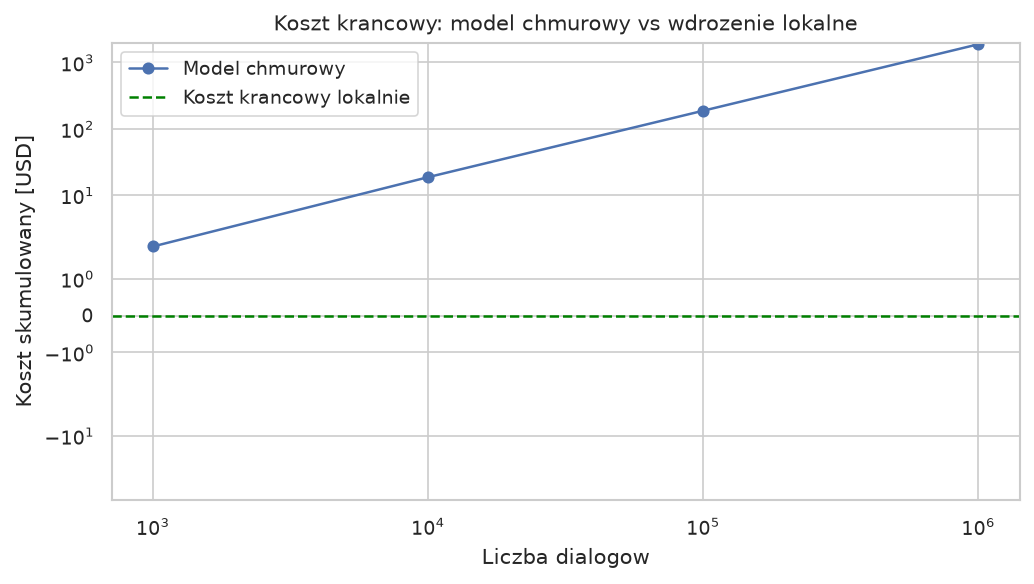

In [ ]:
# PRICE_IN_PER_1M = 2.50    # USD / 1M tokenow wejsciowych — ZWERYFIKUJ
# PRICE_OUT_PER_1M = 10.00  # USD / 1M tokenow wyjsciowych — ZWERYFIKUJ
# PRICING_SOURCE_DATE = "dostep: <uzupelnij>"

# DIALOGS = [1_000, 10_000, 100_000, 1_000_000]

# med_in = df_warm["prompt_tokens"].median()
# med_out = df_warm["output_tokens"].median()
# cost_per_dialog = (med_in / 1e6) * PRICE_IN_PER_1M + (med_out / 1e6) * PRICE_OUT_PER_1M

# cost_tab = pd.DataFrame({
#     "Liczba dialogow": DIALOGS,
#     "Koszt API [USD]": [round(cost_per_dialog * n, 2) for n in DIALOGS],
#     "Koszt krancowy lokalnie [USD]": [0.0] * len(DIALOGS),
# })
# cost_tab.to_csv(OUT / "tables" / "koszt.csv", index=False)

# print(f"Mediana tokenow: wejscie={med_in:.0f}, wyjscie={med_out:.0f}")
# print(f"Koszt jednego dialogu w modelu chmurowym: ${cost_per_dialog:.5f}  ({PRICING_SOURCE_DATE})")
# display(cost_tab)

# fig, ax = plt.subplots(figsize=(7, 4))
# ax.plot(cost_tab["Liczba dialogow"], cost_tab["Koszt API [USD]"], marker="o", label="Model chmurowy")
# ax.axhline(0, color="green", ls="--", label="Koszt krancowy lokalnie")
# ax.set(xscale="log", yscale="symlog", xlabel="Liczba dialogow",
#        ylabel="Koszt skumulowany [USD]",
#        title="Koszt krancowy: model chmurowy vs wdrozenie lokalne")
# ax.legend()
# fig.tight_layout()
# save_fig(fig, "rys6_koszt")
# plt.show()

## 10. Podsumowanie do rozdzialu wynikow

In [81]:
best = df_warm[(df_warm["concurrency"] == 1)]
print("=" * 66)
print("PODSUMOWANIE TESTU 1")
print("=" * 66)
print(f"Sprzet:            {ENV.get('gpu_name')} / {ENV.get('gpu_total_vram_mb')} MB VRAM")
print(f"Pomiarow:          {len(df_warm)} (po odrzuceniu rozgrzewki i przeladowan)")
print(f"Powtorzen/warunek: {REPETITIONS}")
print("-" * 66)
for m in sorted(df_warm["model"].unique()):
    g = best[best["model"] == m]
    if g.empty:
        continue
    print(f"{m}:")
    print(f"   TTFT (stan ustalony)  mediana {g['ttft_warm_ms'].median():7.0f} ms "
          f"| p95 {np.percentile(g['ttft_warm_ms'].dropna(), 95):7.0f} ms")
    print(f"   Czas calkowity        mediana {g['wall_ms'].median():7.0f} ms "
          f"| p95 {np.percentile(g['wall_ms'].dropna(), 95):7.0f} ms")
    print(f"   Narzut orkiestracji   mediana {g['orchestration_ms'].median():7.0f} ms")
    print(f"   Przepustowosc         mediana {g['tps'].median():7.1f} tok/s")
    print(f"   Ponizej 2 s           {(g['wall_ms'] < T_MASKED_MS).mean()*100:7.1f} %")
if len(reloads):
    print("-" * 66)
    print(f"Zimny start (pierwsza interakcja): mediana {reloads['ttft_cold_ms'].median():.0f} ms")
print("=" * 66)
print(f"\nTabele -> {OUT/'tables'}\nWykresy -> {OUT/'figures'}")

PODSUMOWANIE TESTU 1
Sprzet:            NVIDIA GeForce RTX 5070 Ti / 16303 MB VRAM
Pomiarow:          70 (po odrzuceniu rozgrzewki i przeladowan)
Powtorzen/warunek: 2
------------------------------------------------------------------
llama3.1:latest:
   TTFT (stan ustalony)  mediana      17 ms | p95      18 ms
   Czas calkowity        mediana     442 ms | p95     620 ms
   Narzut orkiestracji   mediana      46 ms
   Przepustowosc         mediana   115.8 tok/s
   Ponizej 2 s             100.0 %

Tabele -> results/tables
Wykresy -> results/figures
